##Load the fMRI Nifti file

In [3]:
import nibabel as nib

In [4]:
fmri_filepath = "/home/chsinchi/Hsin-Chi_Project/3814/swra0_sub-ident01_task-tomloc2_run-04_echo-3_bold.nii"

In [5]:
fmri_img = nib.load(fmri_filepath)
print(fmri_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (79, 95, 79, 162)
affine:
[[  -2.    0.    0.   78.]
 [   0.    2.    0. -112.]
 [   0.    0.    2.  -70.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  79  95  79 162   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  2.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Warped - conv(8,8,8)'
aux_file        : b''
qform_code      :

##Using an atlas

In [6]:
from nilearn import datasets

In [7]:
atlas_dataset = datasets.fetch_atlas_difumo(data_dir="/home/chsinchi/Hsin-Chi_Project/3814", dimension=64)
atlas_filepath = atlas_dataset.maps
labels = atlas_dataset.labels

[fetch_atlas_difumo] Dataset found in /home/chsinchi/Hsin-Chi_Project/3814/difumo_atlases

DiFuMo is an overlapping regions so I use a NiftiMapsMasker.

In [8]:
from nilearn.input_data import NiftiMapsMasker
import matplotlib.pyplot as plt

/tmp/ipykernel_1370/4182725029.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMapsMasker


In [9]:
atlas_masker = NiftiMapsMasker(maps_img=atlas_filepath, standardize='zscore_sample', memory='nilearn_cache', memory_level=1)
time_series = atlas_masker.fit_transform(fmri_filepath)
time_series.shape

(162, 64)

###plot the time series in the 35 ROI (vmPFC)

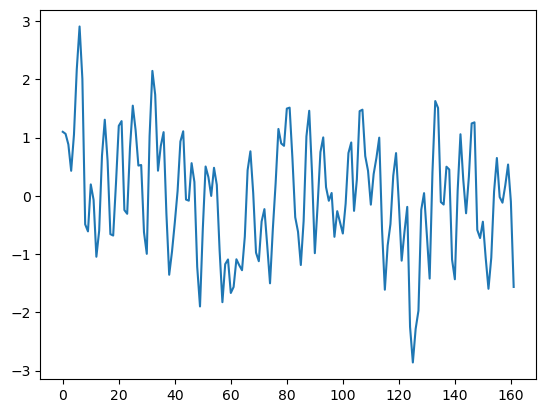

In [10]:
plt.plot(time_series[:,35])

##compute and plot a correlation matrix

In [11]:
from nilearn.connectome import ConnectivityMeasure
import numpy as np
from nilearn import plotting


In [26]:
correlation_measure = ConnectivityMeasure(kind='correlation', standardize='zscore_sample')
correlation_matrix = correlation_measure.fit_transform([time_series])[0]
type(correlation_matrix)

numpy.ndarray

In [ ]:
import pandas as pd
import numpy as np

print(correlation_matrix)
print(f"correlation matrix shape: {correlation_matrix.shape}")
np.save('cor_value.npy',correlation_matrix)



[[       nan 0.32980558 0.13972409 ... 0.76477134 0.394226   0.6316248 ]
 [0.32980558        nan 0.32833216 ... 0.3548662  0.64440876 0.57374096]
 [0.13972408 0.3283322         nan ... 0.25283825 0.30430743 0.178271  ]
 ...
 [0.76477134 0.3548662  0.25283825 ...        nan 0.32965717 0.6351241 ]
 [0.39422604 0.6444087  0.30430743 ... 0.32965717        nan 0.5230075 ]
 [0.63162476 0.57374096 0.178271   ... 0.6351241  0.5230075         nan]]
correlation matrix shape: (64, 64)


In [36]:
np.load('cor_value.npy')

array([[       nan, 0.32980558, 0.13972409, ..., 0.76477134, 0.394226  ,
        0.6316248 ],
       [0.32980558,        nan, 0.32833216, ..., 0.3548662 , 0.64440876,
        0.57374096],
       [0.13972408, 0.3283322 ,        nan, ..., 0.25283825, 0.30430743,
        0.178271  ],
       ...,
       [0.76477134, 0.3548662 , 0.25283825, ...,        nan, 0.32965717,
        0.6351241 ],
       [0.39422604, 0.6444087 , 0.30430743, ..., 0.32965717,        nan,
        0.5230075 ],
       [0.63162476, 0.57374096, 0.178271  , ..., 0.6351241 , 0.5230075 ,
               nan]], shape=(64, 64), dtype=float32)

In [ ]:
df_cor = pd.DataFrame(correlation_matrix)
df_cor.to_csv("correlation_values.csv")

In [28]:
np.fill_diagonal(correlation_matrix, np.nan)

In [17]:
print(
    f" max:  {np.nanmax(correlation_matrix)} \n",
    f"min: {np.nanmin(correlation_matrix)} \n",
    f"mean: {np.nanmean(correlation_matrix)} \n",
    f"std: {np.nanstd(correlation_matrix)} \n",
    f"median: {np.nanmedian(correlation_matrix)} \n"
    )

 max:  0.91402268409729 
 min: -0.2825179100036621 
 mean: 0.3878251314163208 
 std: 0.19596441090106964 
 median: 0.3872646689414978 



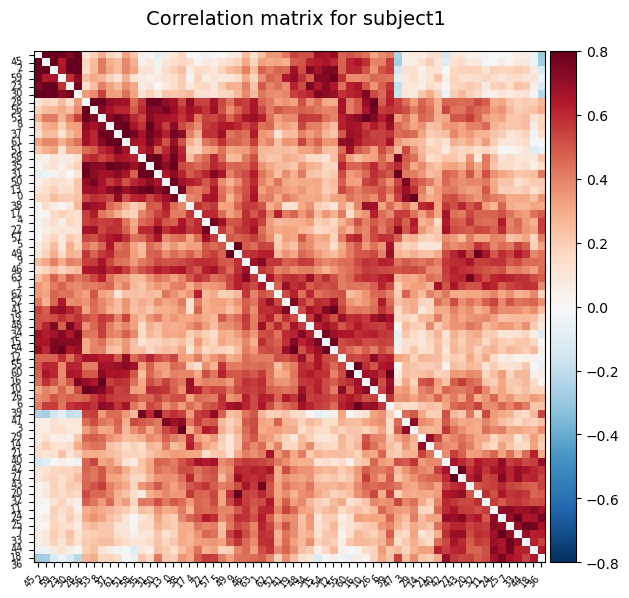

In [18]:
np.fill_diagonal(correlation_matrix, 0)

fig, axes = plt.subplots(1, 1, figsize=(7, 7))
fig.suptitle(" Correlation matrix for subject1 ", y=0.92, fontsize=14)

_ = plotting.plot_matrix(correlation_matrix,  labels=range(time_series.shape[-1]),
                     vmax=0.8, vmin=-0.8, auto_fit=True, reorder='complete', axes=axes)